# Notebook 1: EDA and Corpus Preprocessing

---
**Machine Learning Applications —  Final Project**

Dataset: Google Play Store Games

Group project for Machine Learning Applications
---

In [1]:
# Common imports
import numpy as np
import pandas as pd
from termcolor import colored
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = [10, 6]

from IPython.display import HTML, display

print(colored('Imports loaded successfully ✓', 'green'))

Imports loaded successfully ✓


## 1. Data Loading

In [2]:
# Load datasets
df_games = pd.read_csv('../data/dataset_games.csv')
df_interactions = pd.read_csv('../data/dataset_interactions.csv')

# Rename columns to match our pipeline
df_games = df_games.rename(columns={'score': 'rating'})

print(colored('============= Games Dataset =============', 'blue'))
print(f'Shape: {df_games.shape}')
print(f'Columns: {list(df_games.columns)}')

print(colored('\n============= Interactions Dataset =============', 'blue'))
print(f'Shape: {df_interactions.shape}')
print(f'Columns: {list(df_interactions.columns)}')

============= Games Dataset =============
Shape: (564, 8)
Columns: ['app_id', 'title', 'genre', 'url', 'description', 'rating', 'ratings', 'reviews']

============= Interactions Dataset =============
Shape: (13837, 4)
Columns: ['player_id', 'app_id', 'rating', 'at']


## 2. Exploratory Data Analysis (EDA)

In [3]:
# Basic statistics of the games dataset
print(colored('============= Games Dataset - First rows =============', 'blue'))
display(df_games.head())

print(colored('\n============= Data types and null values =============', 'blue'))
print(df_games.dtypes)
print('\nNull values per column:')
print(df_games.isnull().sum())

============= Games Dataset - First rows =============


,app_id,title,genre,url,description,rating,ratings,reviews
0,ai.character.app,"Character AI: Chat, Talk, Text",Entretenimiento,https://play.google.com/store/apps/details?id=...,✨Character.AI no es solo otra aplicación de co...,1.362544,2253536.0,6382.0
1,air.com.bmapps.gossipgirlsdivasinhighschool,Gossip Girls Divas Highschool,Entretenimiento,https://play.google.com/store/apps/details?id=...,Estas tres chicas de secundaria quieren ser di...,3.558442,15228.0,30.0
2,air.com.buffalo_studios.newflashbingo,Bingo Blitz™️: juegos de Bingo,Juegos de mesa,https://play.google.com/store/apps/details?id=...,Experimenta tu juego de bingo en línea como nu...,4.429238,1417570.0,2475.0
3,air.com.flipline.papascheeseriatogo,Papa's Cheeseria To Go!,Estrategia,https://play.google.com/store/apps/details?id=...,-- SOBRE EL JUEGO --\r\n\r\n¡Papa's Cheeseria ...,4.739130,2293.0,2.0
4,air.com.flipline.papascluckeriatogo,Papa's Cluckeria To Go!,Estrategia,https://play.google.com/store/apps/details?id=...,-- SOBRE EL JUEGO --\r\n\r\n¡La Guerra de los ...,4.772728,2122.0,9.0



============= Data types and null values =============
app_id             str
title              str
genre              str
url                str
description        str
rating         float64
ratings        float64
reviews        float64
dtype: object

Null values per column:
app_id           0
title            0
genre            0
url              0
description      0
rating         112
ratings        112
reviews        112
dtype: int64


### 2.1 Genre distribution

============= Genre Distribution =============
genre
Puzles                        61
Acción                        58
Casuales                      37
Deportes                      36
Arcade                        34
Estrategia                    32
Simulación                    26
Juegos de rol                 24
Herramientas                  20
Entretenimiento               18
Salud y bienestar             18
Empresa                       15
Juegos de mesa                14
Aventura                      13
Carreras                      13
Cartas                        12
Productividad                 11
Finanzas                      11
Estilo de vida                10
Música y audio                 9
Educación                      8
Compras                        8
Social                         8
Comunicación                   8
Comer y beber                  7
Arte y diseño                  6
Música                         5
Viajes y guías                 5
Palabras               

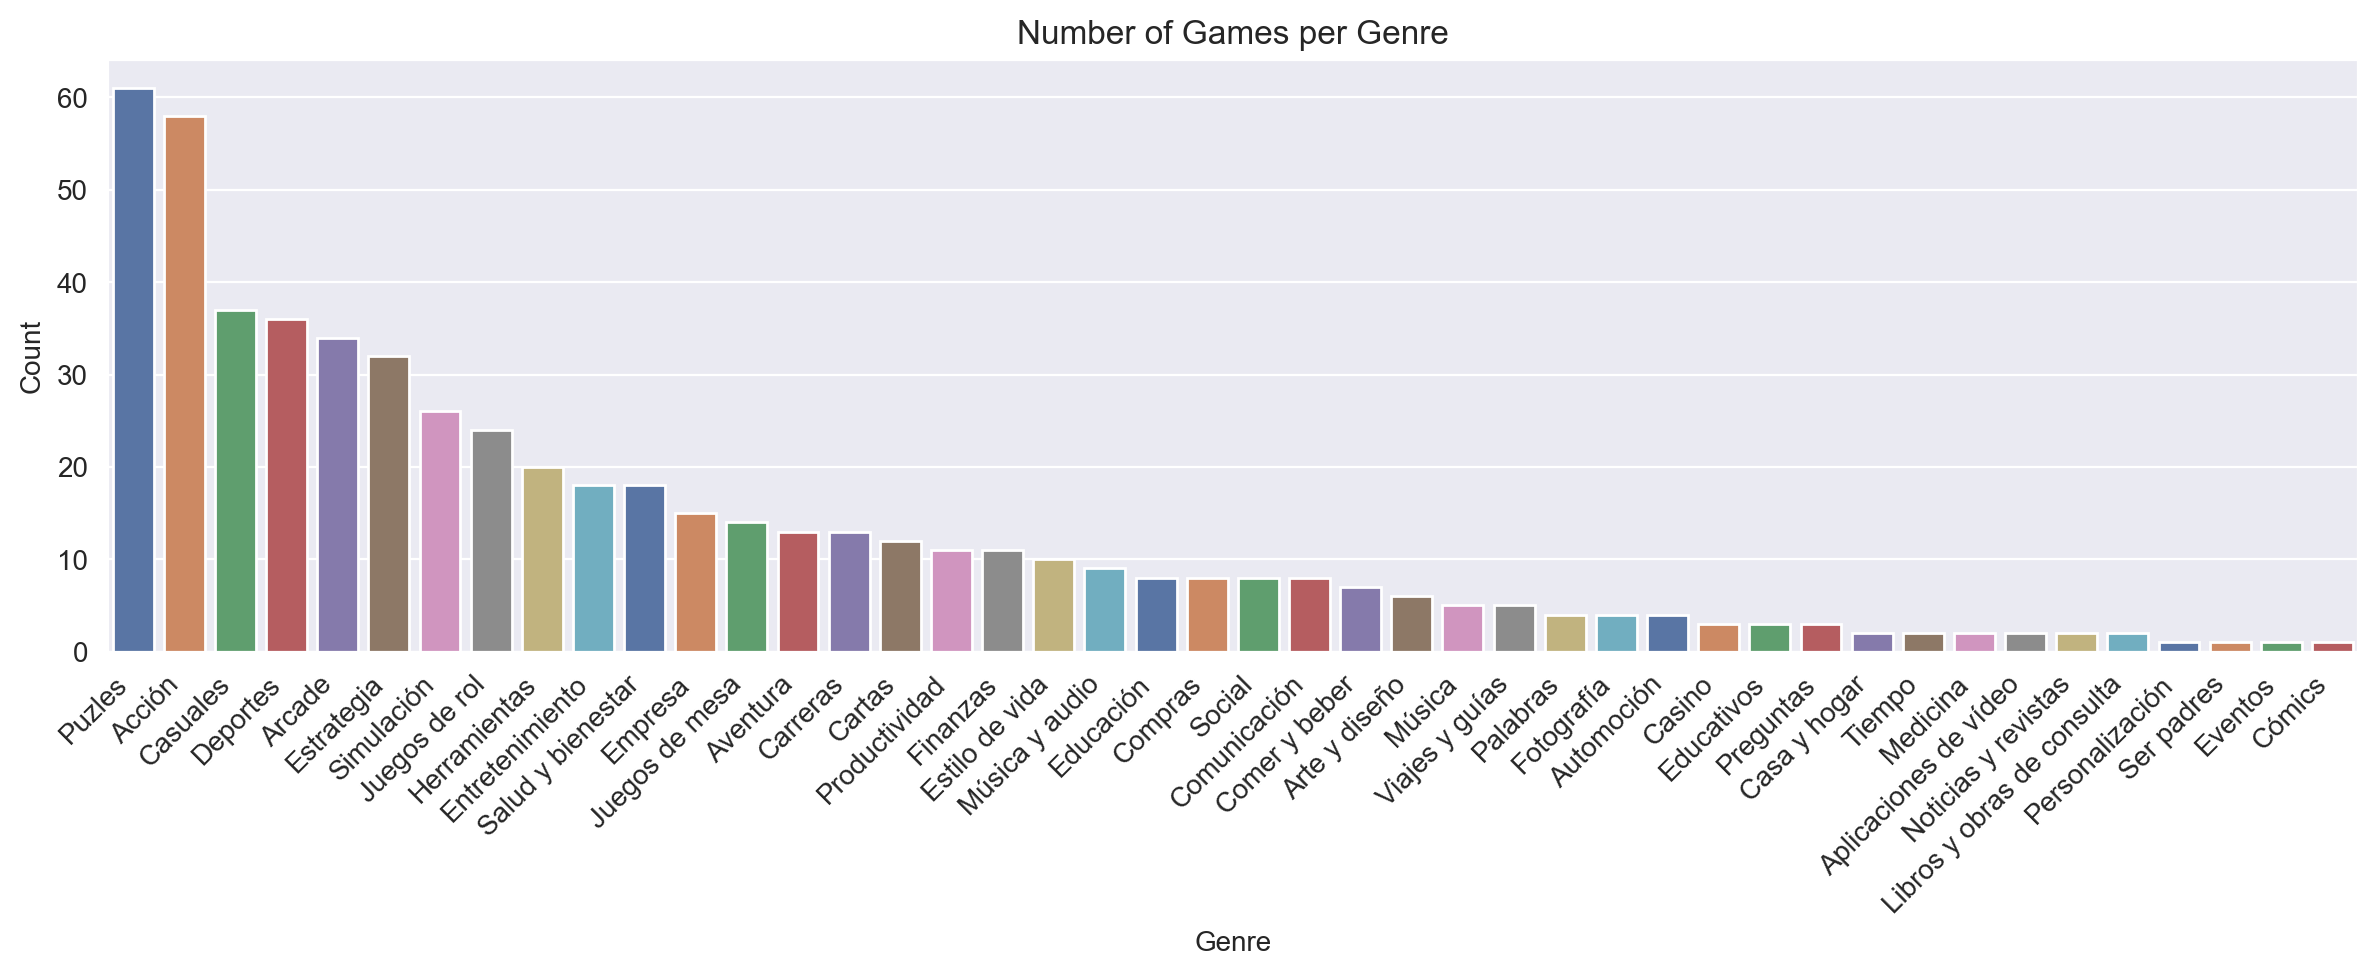

In [4]:
# Genre distribution
print(colored('============= Genre Distribution =============', 'blue'))
genre_counts = df_games['genre'].value_counts()
print(genre_counts)

plt.figure(figsize=(12, 5))
sns.barplot(x=genre_counts.index, y=genre_counts.values, hue=genre_counts.index, legend=False, palette='deep')
plt.title('Number of Games per Genre')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 2.2 Game rating distribution

============= Games Rating Distribution =============
count    452.000000
mean       4.012860
std        1.141755
min        0.000000
25%        4.027500
50%        4.358734
75%        4.590000
max        4.974875
Name: rating, dtype: float64
Dataset size after removing 0 ratings: 536


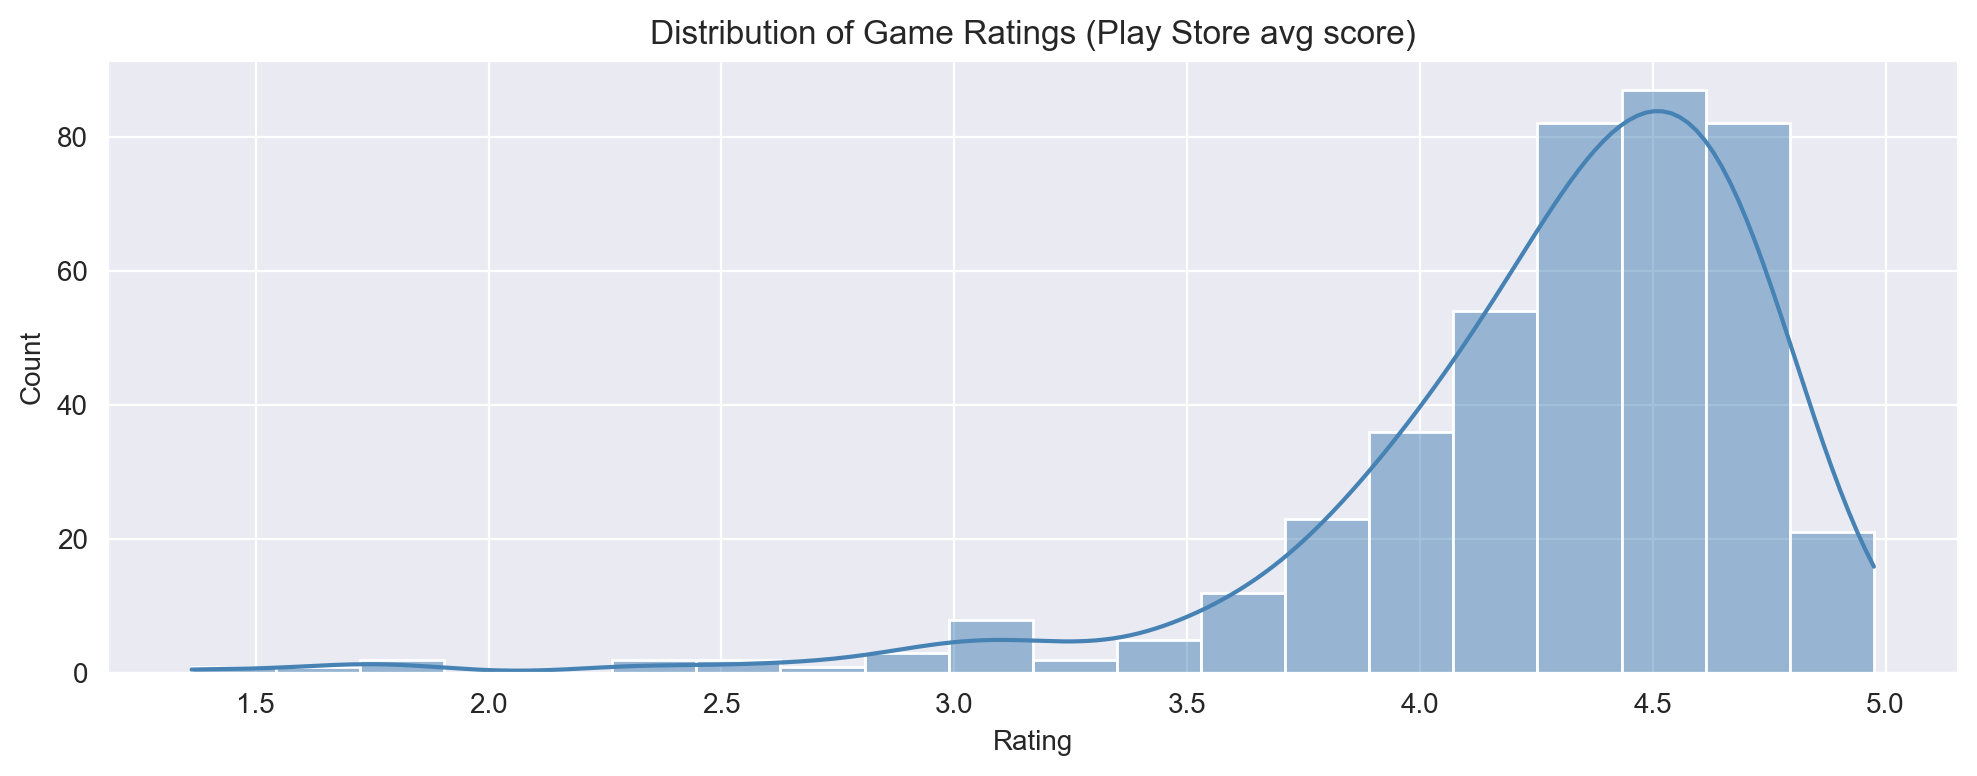

In [5]:
# Rating distribution of games
print(colored('============= Games Rating Distribution =============', 'blue'))
print(df_games['rating'].describe())

df_games = df_games[df_games['rating'] != 0].reset_index(drop=True)
print(f"Dataset size after removing 0 ratings: {len(df_games)}")


plt.figure(figsize=(10, 4))
sns.histplot(df_games['rating'], bins=20, kde=True, color='steelblue')
plt.title('Distribution of Game Ratings (Play Store avg score)')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 2.3 Description length analysis

============= Description Length (words) =============
count    536.000000
mean     339.783582
std      184.400047
min        5.000000
25%      174.750000
50%      337.000000
75%      493.000000
max      769.000000
Name: desc_length, dtype: float64


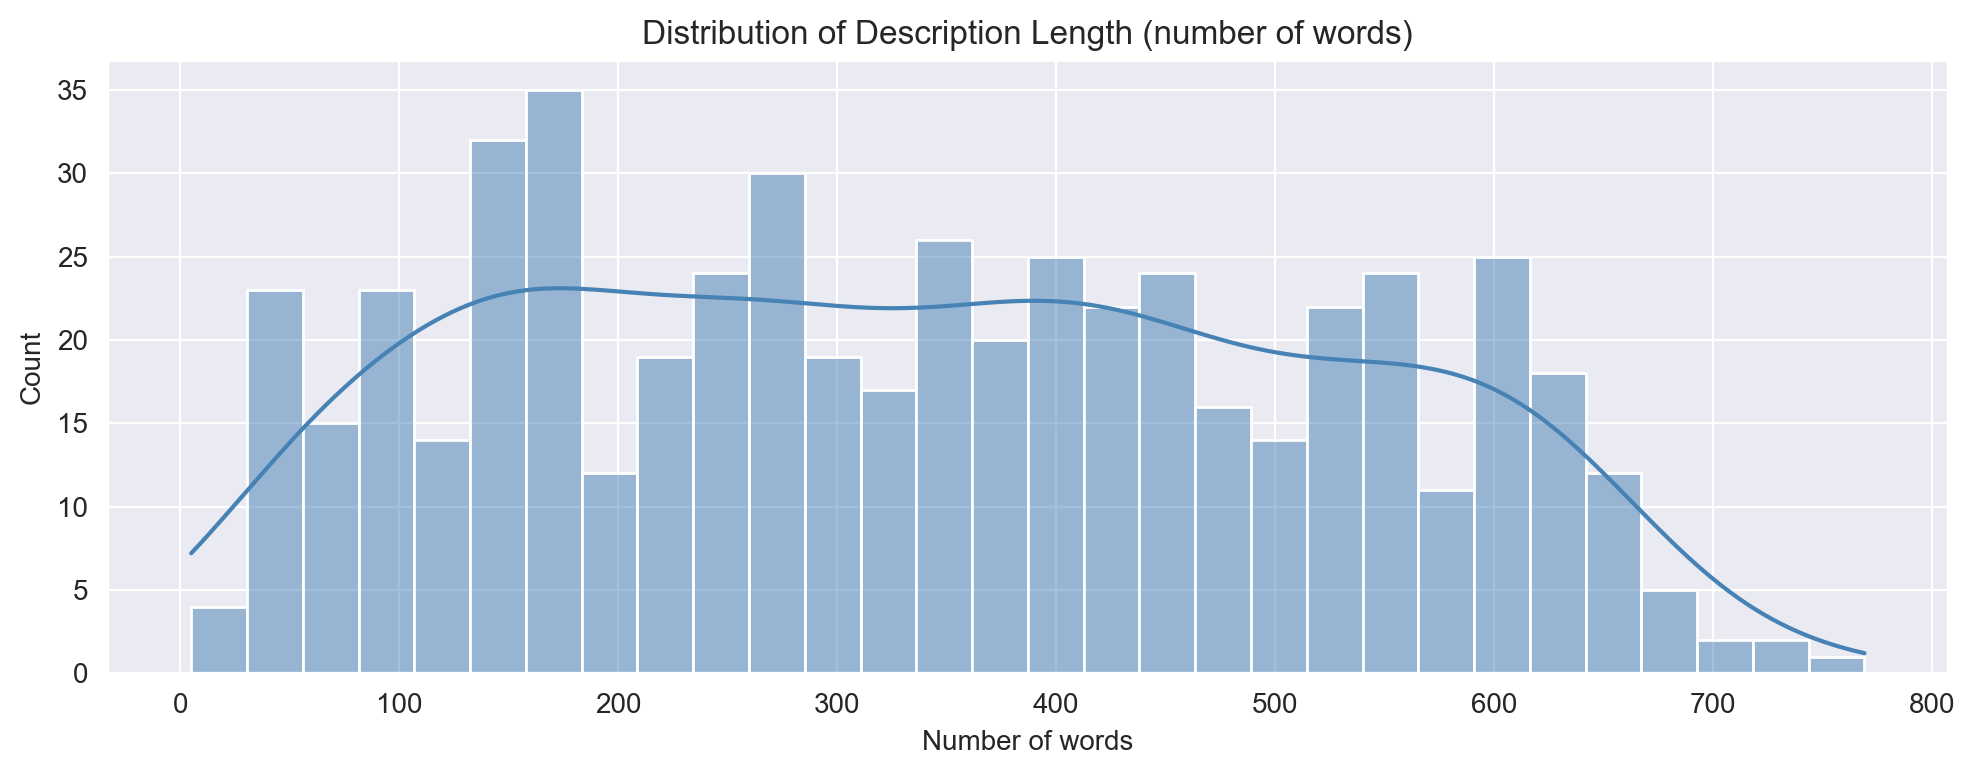

In [6]:
# Description length analysis
df_games['desc_length'] = df_games['description'].apply(lambda x: len(str(x).split()))

print(colored('============= Description Length (words) =============', 'blue'))
print(df_games['desc_length'].describe())

plt.figure(figsize=(10, 4))
sns.histplot(df_games['desc_length'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Description Length (number of words)')
plt.xlabel('Number of words')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 2.4 Interactions dataset analysis

============= Interactions Dataset =============
Total interactions: 13837
Unique players: 1548
Unique games: 467
Matrix density: 1.91%

============= User Rating Distribution =============
rating
1    3137
2     978
3    1269
4    1985
5    6468
Name: count, dtype: int64


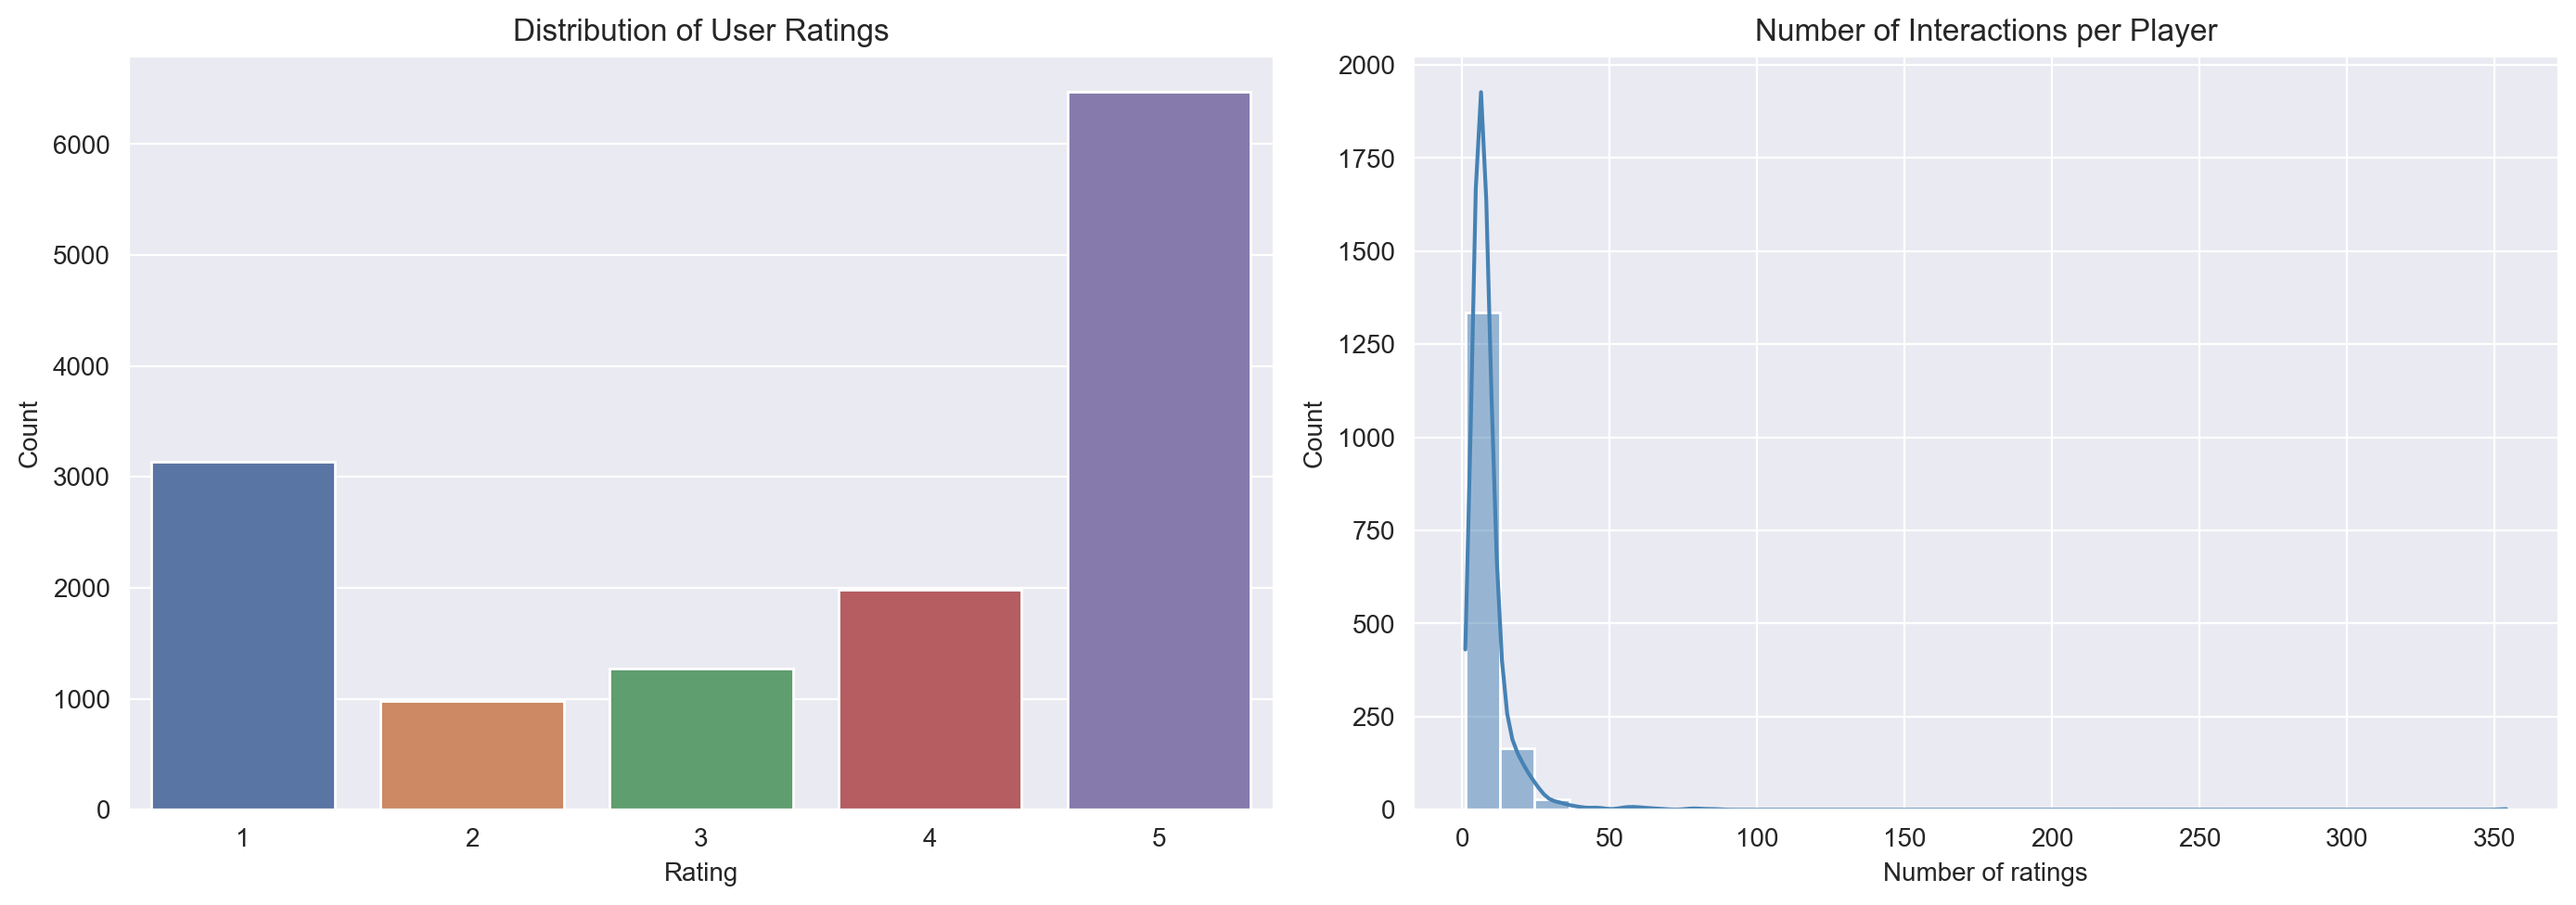

In [7]:
# Interactions analysis
print(colored('============= Interactions Dataset =============', 'blue'))
print(f'Total interactions: {len(df_interactions)}')
print(f'Unique players: {df_interactions["player_id"].nunique()}')
print(f'Unique games: {df_interactions["app_id"].nunique()}')

sparsity = len(df_interactions) / (df_interactions["player_id"].nunique() * df_interactions["app_id"].nunique()) * 100
print(f'Matrix density: {sparsity:.2f}%')

print(colored('\n============= User Rating Distribution =============', 'blue'))
print(df_interactions['rating'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='rating', data=df_interactions, ax=axes[0], hue='rating', legend=False, palette='deep')
axes[0].set_title('Distribution of User Ratings')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

interactions_per_user = df_interactions.groupby('player_id').size()
sns.histplot(interactions_per_user, bins=30, kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Number of Interactions per Player')
axes[1].set_xlabel('Number of ratings')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### 2.5 Average rating per genre

============= Average Rating per Genre =============
genre
Viajes y guías                4.888889
Ser padres                    4.740000
Tiempo                        4.712131
Estilo de vida                4.682956
Palabras                      4.639789
Aplicaciones de vídeo         4.614663
Educación                     4.559755
Finanzas                      4.557533
Libros y obras de consulta    4.538462
Fotografía                    4.523871
Música                        4.492785
Compras                       4.492214
Casino                        4.415316
Música y audio                4.409804
Puzles                        4.397969
Cartas                        4.394406
Estrategia                    4.392136
Juegos de mesa                4.390515
Salud y bienestar             4.383030
Eventos                       4.366337
Arte y diseño                 4.349815
Preguntas                     4.344259
Carreras                      4.327732
Comunicación                  4.310712
Acció

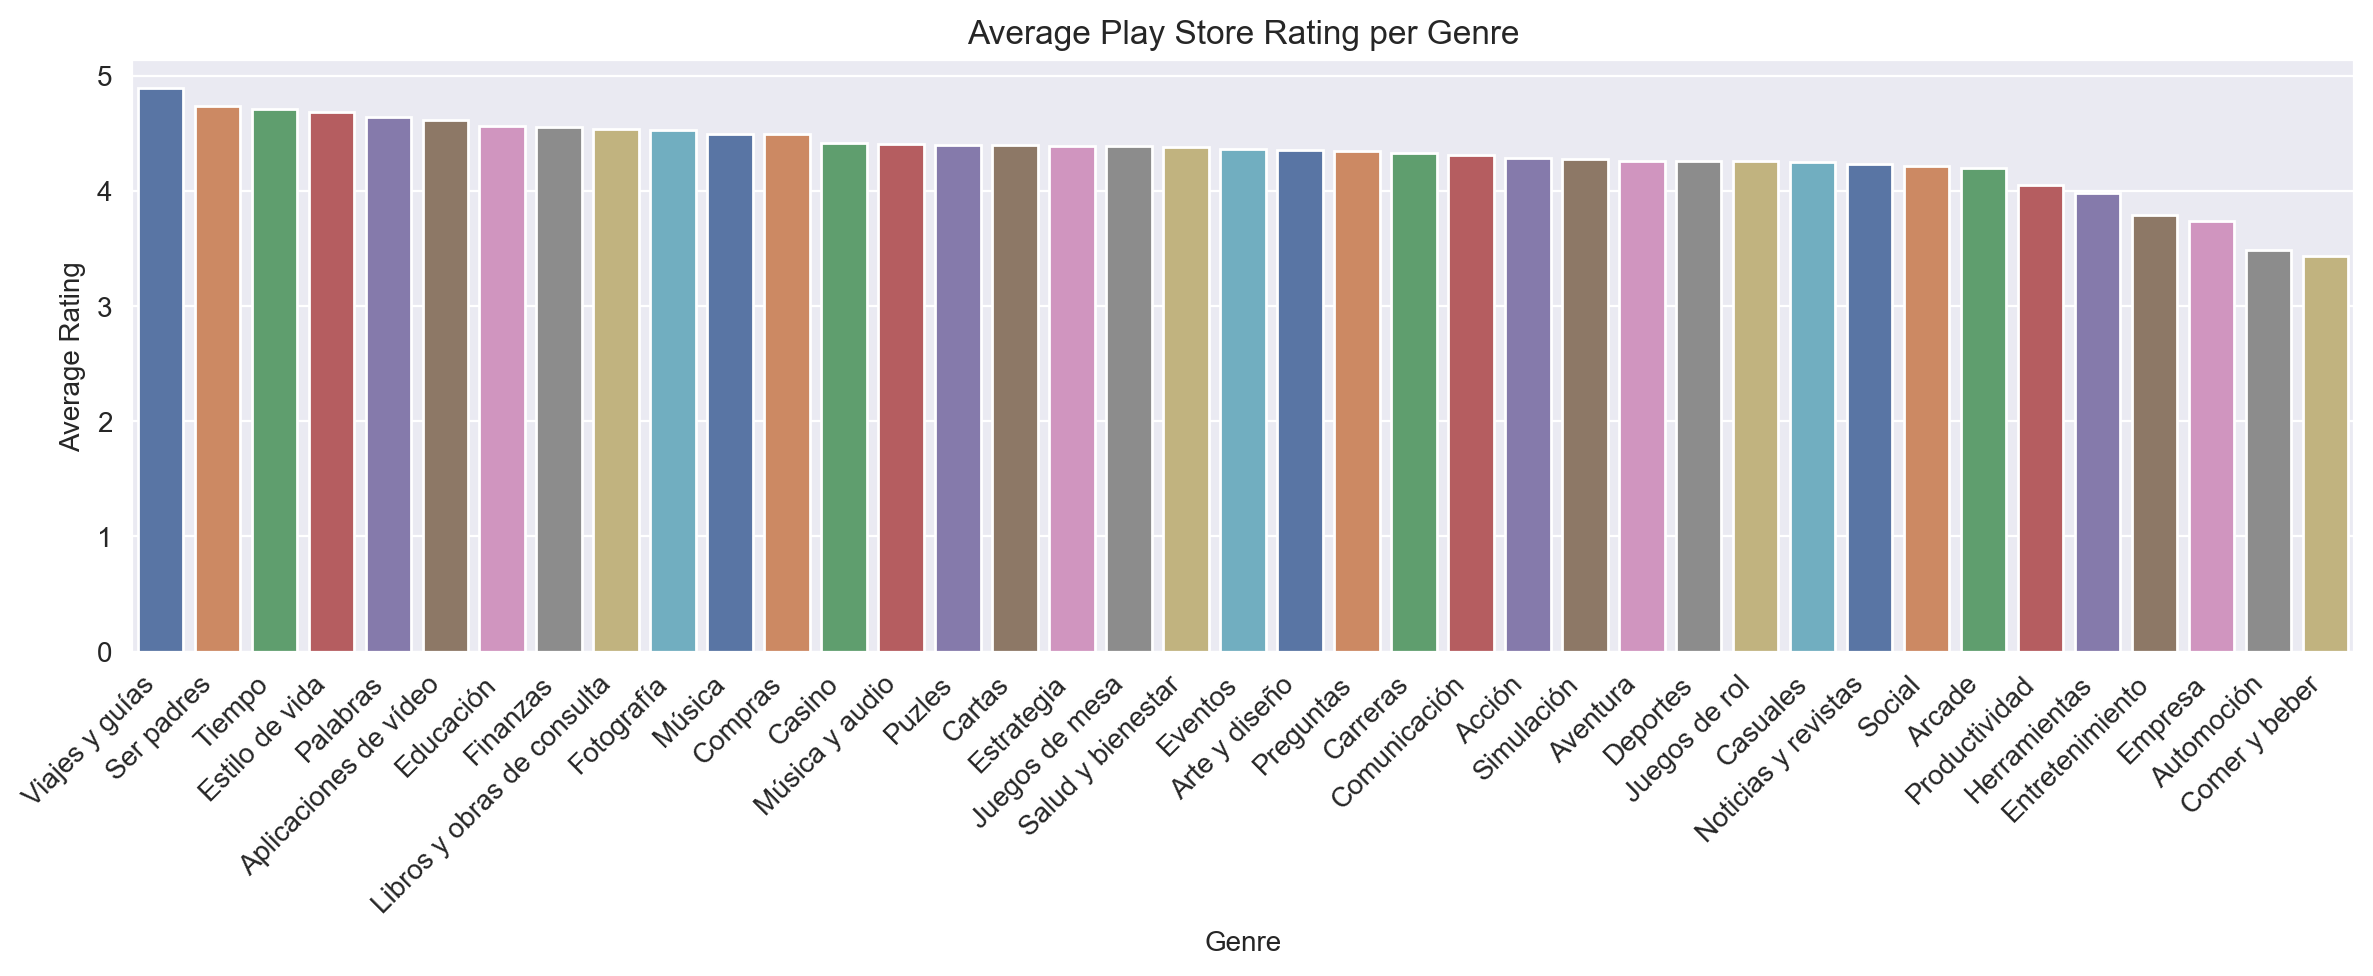

In [8]:
# Average Play Store rating per genre
avg_rating_genre = df_games.groupby('genre')['rating'].mean().dropna().sort_values(ascending=False)

print(colored('============= Average Rating per Genre =============', 'blue'))
print(avg_rating_genre)

plt.figure(figsize=(12, 5))
sns.barplot(x=avg_rating_genre.index, y=avg_rating_genre.values,
            hue=avg_rating_genre.index, legend=False, palette='deep')
plt.title('Average Play Store Rating per Genre')
plt.xlabel('Genre')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 2.6 Synchronize datasets


In [9]:
df_games = df_games[df_games['app_id'].isin(df_interactions['app_id'])].reset_index(drop=True)
print(f"Games after filtering: {len(df_games)}")

df_interactions = df_interactions[df_interactions['app_id'].isin(df_games['app_id'])].reset_index(drop=True)
print(f"Interactions after filtering: {len(df_interactions)}")

Games after filtering: 445
Interactions after filtering: 13722


## 3. Text Preprocessing Pipeline (SpaCy)

In [10]:
import spacy
from spacy.language import Language
from spacy_langdetect import LanguageDetector

# Load Spanish model for descriptions
nlp = spacy.load('es_core_news_md')
nlp.disable_pipe('parser')
nlp.disable_pipe('ner')

# Multilingual model for sentence tokenization
mult_nlp = spacy.load('xx_sent_ud_sm')

if not Language.has_factory("language_detector"):
    @Language.factory("language_detector")
    def create_language_detector(nlp, name):
        return LanguageDetector(language_detection_function=None)

mult_nlp.add_pipe('language_detector', last=True)

print(colored('Models loaded successfully ✓', 'green'))
print(colored(f'es_core_news_md pipeline: {nlp.pipe_names}', 'blue'))

Models loaded successfully ✓
es_core_news_md pipeline: ['tok2vec', 'morphologizer', 'attribute_ruler', 'lemmatizer']


### 3.1 Preprocessing function

In [11]:
# Valid POS tags to keep (same logic, Spanish model)
valid_POS = {'NOUN', 'VERB', 'ADJ', 'PROPN'}

# Domain-specific stopwords for mobile games
specific_stw = {'juego', 'jugar', 'jugador', 'gratis', 'nuevo', 'app', 
                'game', 'play', 'player', 'free', 'new', 'get', 'feature'}
for word in specific_stw:
    nlp.vocab[word].is_stop = True

def text_preprocessing(rawtext):
    """
    Preprocessing pipeline for game descriptions (Spanish):
    1. Sentence tokenization + language detection (multilingual model)
    2. Filter Spanish and English sentences (descriptions mix both)
    3. POS tagging + lemmatization (Spanish model es_core_news_md)
    4. Keep only alphanumeric tokens
    5. Keep only NOUN, VERB, ADJ, PROPN — removes function words
    6. Remove stopwords (spaCy built-in + domain-specific)
    Returns: preprocessed string (space-separated lemmas)
    """
    processed_tokens = []
    doc_multi = mult_nlp(rawtext)
    
    for sent in doc_multi.sents:
        try:
            lang = sent._.language['language']
        except:
            lang = 'es'  # default to Spanish if detection fails
        
        # Process Spanish and English sentences
        # (many descriptions include English keywords like "RPG", "FPS", etc.)
        if lang in ('es', 'en'):
            doc = nlp(sent.text)
            tokens = [
               token.lemma_.lower()
               for token in doc
               if token.is_alpha
               and not token.is_stop
               and token.pos_ in valid_POS
               and len(token.lemma_) > 1    
            ]
            processed_tokens.extend(tokens)
    
    return ' '.join(processed_tokens)

print(colored('Preprocessing function defined ✓', 'green'))

Preprocessing function defined ✓


### 3.2 Pipeline test on a single description

In [12]:
# Test the pipeline on one example
sample = df_games['description'].iloc[0]
print(colored('============= Original description =============', 'blue'))
print(sample[:500])

processed = text_preprocessing(sample)
print(colored('\n============= Processed description =============', 'red'))
print(processed[:500])
print(colored(f'\nOriginal words: {len(sample.split())} | Processed tokens: {len(processed.split())}', 'green'))

============= Original description =============
✨Character.AI no es solo otra aplicación de conversación con IA: es un patio de recreo infinito para tu imaginación, creatividad y exploración. 

Sumérgete en conversaciones inmersivas, crea tus propios chatbots de IA y únete a una comunidad vibrante de creadores como tú.

Envía mensajes de texto o habla: ¡tu próxima aventura comienza aquí!

📱Conversa, llama, envía mensajes de texto y crea con personajes de IA que responden de manera inteligente, recuerdan conversaciones pasadas y se adapt

============= Processed description =============
character ai aplicación conversación ia patio recreo infinito imaginación creatividad exploración sumérgete conversación inmersiva creer chatbot ia únetir comunidad vibrante creador enviar mensaje texto próximo aventura comenzar conversa llamar enviar mensaje texto creer personaje ia responder inteligente recordar conversación pasado adaptar estilo conversación ia sentir natural atrapante único explora

### 3.3 Apply pipeline to full corpus

In [13]:
from tqdm import tqdm
tqdm.pandas()

print(colored('Applying preprocessing pipeline to all descriptions...', 'blue'))
df_games['processed_description'] = df_games['description'].progress_apply(text_preprocessing)

print(colored('\nPreprocessing complete ✓', 'green'))
print(colored(f'Games processed: {len(df_games)}', 'green'))

# Verify results
print(colored('\n============= Sample result =============', 'blue'))
print(colored('Original:', 'red'))
print(df_games['description'].iloc[1][:300])
print(colored('\nProcessed:', 'red'))
print(df_games['processed_description'].iloc[1])

Applying preprocessing pipeline to all descriptions...


100%|██████████| 445/445 [01:13<00:00,  6.01it/s]


Preprocessing complete ✓
Games processed: 445

============= Sample result =============
Original:
Estas tres chicas de secundaria quieren ser divas reales y en su horario se programa una nueva recopilación de chismes por lo que todos tienen que mirar perfecto para ello. Ven a jugar a este juego de maquillaje para gestionar tres personajes diferentes. Va a hacer algunos tratamientos faciales y má

Processed:
chica secundaria querer diva real horario programar recopilación chism mirar perfecto ven maquillaje gestionar personaje tratamiento facial máscaro continuación maquillaje natural elección equipo difícil niña lugar aplicar lavadora cara eliminar suciedad infiltrar piel bastar quitar agua tibio vida real hidratar cara necesario agregar crema facial propiedad terapéutico ceja ver desordenado cuidar eliminar grano mantener superficie limpio liso casa hecho máscara hacer cara suave listo comenzar fase maquillaje encontrar crear look perfecto maquillaje talento moda obtener aspecto des

### 3.4 Processed description length analysis

============= Processed Description Length (tokens) =============
count    445.000000
mean     178.087640
std       88.337671
min        2.000000
25%      106.000000
50%      181.000000
75%      248.000000
max      367.000000
Name: processed_length, dtype: float64


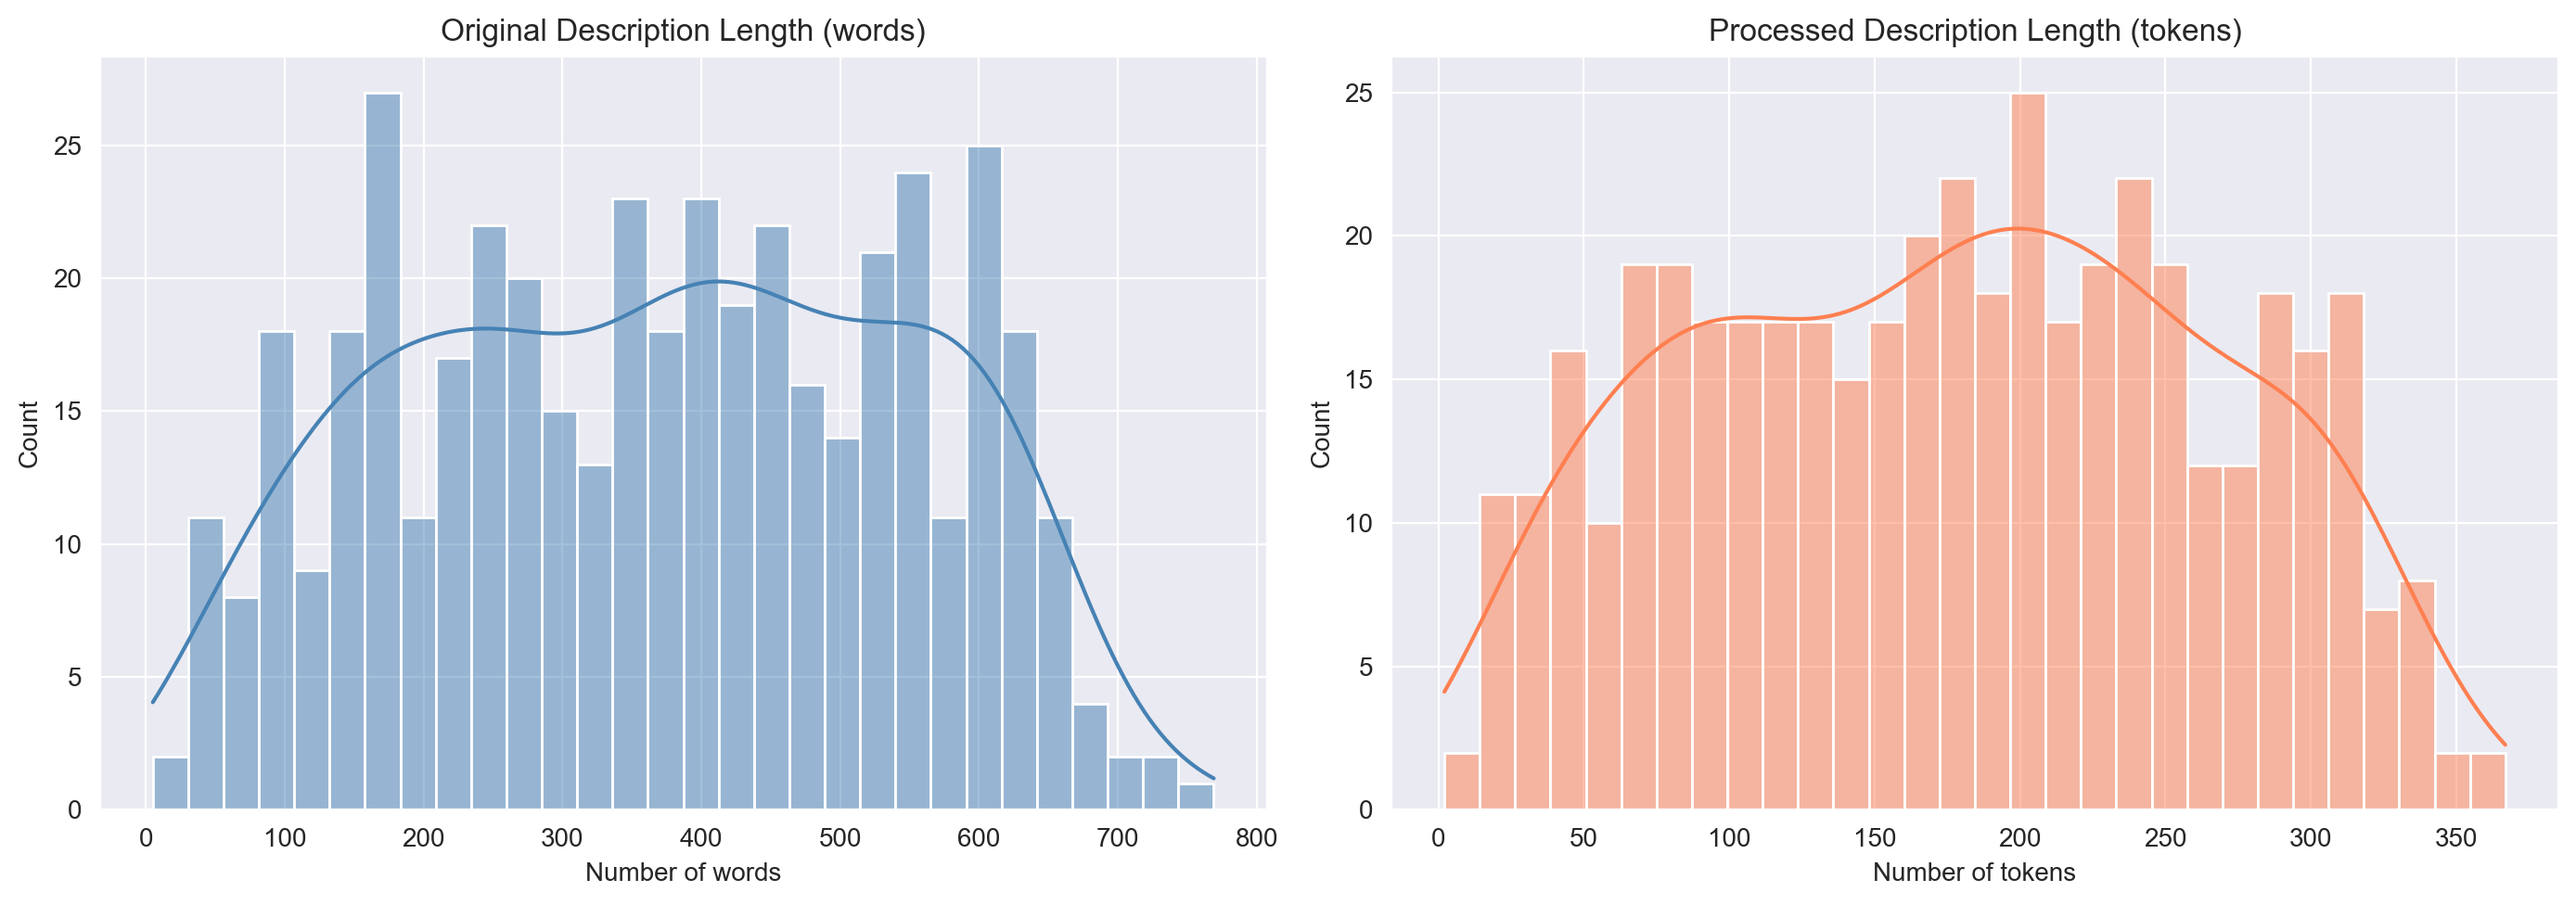


Average compression ratio: 48.44%


In [14]:
# Compare description lengths before and after preprocessing
df_games['processed_length'] = df_games['processed_description'].apply(lambda x: len(str(x).split()))

print(colored('============= Processed Description Length (tokens) =============', 'blue'))
print(df_games['processed_length'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_games['desc_length'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Original Description Length (words)')
axes[0].set_xlabel('Number of words')
axes[0].set_ylabel('Count')

sns.histplot(df_games['processed_length'], bins=30, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Processed Description Length (tokens)')
axes[1].set_xlabel('Number of tokens')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(colored(f'\nAverage compression ratio: {df_games["processed_length"].mean() / df_games["desc_length"].mean():.2%}', 'green'))

## 4. Save Preprocessed Dataset

In [15]:
# Save the preprocessed dataset for the other team members
output_path = '../data/dataset_games_preprocessed.csv'
df_games.to_csv(output_path, index=False, encoding='utf-8')

print(colored(f'Dataset saved to {output_path} ✓', 'green'))
print(colored(f'Shape: {df_games.shape}', 'green'))
print(colored(f'Columns: {list(df_games.columns)}', 'green'))

# Quick verification
print(colored('\n============= Sample preprocessed description =============', 'blue'))
print(colored('Original (ES):', 'red'))
print(df_games['description'].iloc[0][:200])
print(colored('\nProcessed:', 'red'))
print(df_games['processed_description'].iloc[0][:200])

Dataset saved to ../data/dataset_games_preprocessed.csv ✓
Shape: (445, 11)
Columns: ['app_id', 'title', 'genre', 'url', 'description', 'rating', 'ratings', 'reviews', 'desc_length', 'processed_description', 'processed_length']

============= Sample preprocessed description =============
Original (ES):
✨Character.AI no es solo otra aplicación de conversación con IA: es un patio de recreo infinito para tu imaginación, creatividad y exploración. 

Sumérgete en conversaciones inmersivas, crea tus pro

Processed:
character ai aplicación conversación ia patio recreo infinito imaginación creatividad exploración sumérgete conversación inmersiva creer chatbot ia únetir comunidad vibrante creador enviar mensaje tex


In [16]:
# Apply preprocessing to the full dataset (536 games, including games without interactions)
# This file is used by notebooks 02, 03, 04 and 05 for vectorization
print(colored('Processing full dataset (536 games)...', 'blue'))

df_games_full = pd.read_csv('../data/dataset_games.csv')
df_games_full = df_games_full.rename(columns={'score': 'rating'})
df_games_full = df_games_full[df_games_full['rating'] != 0].reset_index(drop=True)
df_games_full['desc_length'] = df_games_full['description'].apply(
    lambda x: len(str(x).split())
)

df_games_full['processed_description'] = df_games_full['description'].progress_apply(
    text_preprocessing
)
df_games_full['processed_tokens'] = df_games_full['processed_description'].apply(
    lambda x: x.split()
)
df_games_full['processed_length'] = df_games_full['processed_description'].apply(
    lambda x: len(x.split())
)

df_games_full.to_csv('../data/games_preprocessed.csv', index=False, encoding='utf-8')

print(colored(f'Full dataset saved to ../data/games_preprocessed.csv ✓', 'green'))
print(colored(f'Shape: {df_games_full.shape}', 'green'))
print(colored(f'Single-char tokens removed (len > 1 filter active) ✓', 'green'))

Processing full dataset (536 games)...


100%|██████████| 536/536 [01:11<00:00,  7.54it/s]

Full dataset saved to ../data/games_preprocessed.csv ✓
Shape: (536, 12)
Single-char tokens removed (len > 1 filter active) ✓
